# Exponential Search for Representative Pareto

In [1]:
from paretoKnapsackTeams import *
import shutil
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

# Enable LaTeX rendering if available
if shutil.which("latex"):
    mpl.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "text.latex.preamble": r"\usepackage{amsmath}\usepackage{amssymb}",
    })
else:
    mpl.rcParams.update({"text.usetex": False})

# Set style
# plt.style.use('seaborn-v0_8-darkgrid')
mpl.rcParams['figure.figsize'] = (12, 8)
mpl.rcParams['font.size'] = 10

In [2]:
def Pass(l, r, delta_val, task, experts, costs, size_univ):
    """
    Test if the interval [l, r] passes the chord certification criterion.
    """
    _, v_l = ParetoPoint(task, experts, costs, size_univ, l)
    _, v_r = ParetoPoint(task, experts, costs, size_univ, r)
    _, v_m = ParetoPoint(task, experts, costs, size_univ, (l + r) / 2.0)

    v_L_m = ((r - ((l + r) / 2.0)) / (r - l)) * v_l + ((((l + r) / 2.0) - l) / (r - l)) * v_r
    return v_L_m >= (1 - delta_val) * v_m


def exponentialSearchRepresentativeIntervals(task, experts, costs, size_univ, B_min, B_max, epsilon_val=0.1, delta_val=0.1):
    """
    Exponential search for representative Pareto intervals using budget-specific
    Pareto points.
    """
    startTime = time.perf_counter()
    P_R = []
    l = B_min

    def binary_search_largest_passing(l_left, l_right, r_right):
        lo, hi = l_right, r_right
        while hi - lo > 1e-6:
            mid = (lo + hi) / 2.0
            if Pass(l_left, mid, delta_val, task, experts, costs, size_univ):
                lo = mid
            else:
                hi = mid
        return lo

    iteration = 0
    while l < B_max:
        iteration += 1
        logging.info("Exponential Search Iteration {}: l={}".format(iteration, l))

        r = min(l * ((1 + epsilon_val) ** 2), B_max)
        r_prev = l

        while Pass(l, r, delta_val, task, experts, costs, size_univ):
            logging.debug("Exponential search: Pass(l={}, r={}) = True, advancing r".format(l, r))
            r_prev = r
            r_uncapped = r * ((1 + epsilon_val) ** 2)
            if r_uncapped >= B_max:
                r = B_max
                break
            r = r_uncapped

        if r >= B_max:
            r_prime = r_prev
            logging.debug("Exponential search reached B_max, using r_prev={}".format(r_prev))
        elif Pass(l, r, delta_val, task, experts, costs, size_univ):
            r_prime = r
            logging.debug("Pass(l={}, r={}) = True, setting r'={}".format(l, r, r_prime))
        else:
            r_prime = binary_search_largest_passing(l, r_prev, r)
            logging.debug("Pass(l={}, r={}) = False, binary search returned r'={}".format(l, r, r_prime))

        R_l, v_l = ParetoPoint(task, experts, costs, size_univ, l)
        if v_l >= 1.0 - 1e-6:
            P_R.append((R_l, (l, r_prime)))
            logging.info("Added interval: [l={:.2f}, r'={:.2f}], v_l={:.3f}, experts={}".format(l, r_prime, v_l, len(R_l)))
            logging.info("Full coverage achieved at l={:.2f}, stopping search".format(l))
            break

        P_R.append((R_l, (l, r_prime)))
        logging.info("Added interval: [l={:.2f}, r'={:.2f}], v_l={:.3f}, experts={}".format(l, r_prime, v_l, len(R_l)))
        l = int(r_prime) + 1

    runTime = time.perf_counter() - startTime
    metadata = {
        "epsilon": epsilon_val,
        "delta": delta_val,
        "B_min": B_min,
        "B_max": B_max,
        "num_intervals": len(P_R),
        "runtime": runTime,
    }
    logging.info("Exponential Search Complete: {} intervals found, Runtime={:.2f}s".format(len(P_R), runTime))
    return P_R, metadata

In [3]:
def ParetoPoint(task, experts, costs, size_univ, budget):
    """
    Compute a budget-specific Pareto point by instantiating a new
    paretoKnapsackTeams object with the requested budget.
    """
    if budget <= 0:
        return [], 0.0

    budget_instance = paretoKnapsackTeams(
        task=task,
        n_experts=experts,
        costs=costs,
        size_univ=size_univ,
        budget=budget,
    )

    best_experts, _, best_coverage, _, _ = budget_instance.oneGuessGreedyPlus()
    return best_experts, best_coverage

In [4]:
# Load datasets
print("Loading datasets...")

# IMDB
imdb_experts_1, imdb_tasks_1, imdb_costs_1, imdb_graphmat_1 = import_pickled_datasets('imdb', 1)

# Bibsonomy
bbsm_experts_1, bbsm_tasks_1, bbsm_costs_1, bbsm_graphmat_1 = import_pickled_datasets('bbsm', 1)

# Freelancer
fl_experts_1, fl_tasks_1, fl_costs_1, fl_graphmat_1 = import_pickled_datasets('freelancer', 1)

print(f"IMDB: {len(imdb_experts_1)} experts, {len(imdb_tasks_1)} tasks")
print(f"Bibsonomy: {len(bbsm_experts_1)} experts, {len(bbsm_tasks_1)} tasks")
print(f"Freelancer: {len(fl_experts_1)} experts, {len(fl_tasks_1)} tasks")

# Select dataset to test with
dataset_name = 'imdb'
experts = imdb_experts_1
tasks = imdb_tasks_1
costs = imdb_costs_1

# Parameters
num_experts = min(50, len(experts))
num_tasks = min(5, len(tasks))
max_budget = 500

print(f"\nUsing {dataset_name} dataset with {num_experts} experts, {num_tasks} tasks, budget {max_budget}")

2026-05-18 16:47:31,058 |INFO: Imported imdb experts, Num Experts: 200
2026-05-18 16:47:31,061 |INFO: Imported imdb tasks, Num Tasks: 300
2026-05-18 16:47:31,062 |INFO: Imported imdb costs, Num Costs: 200
2026-05-18 16:47:31,068 |INFO: Imported imdb graph matrix, Shape: (1000, 1000)

2026-05-18 16:47:31,070 |INFO: Imported bbsm experts, Num Experts: 250
2026-05-18 16:47:31,071 |INFO: Imported bbsm tasks, Num Tasks: 300
2026-05-18 16:47:31,072 |INFO: Imported bbsm costs, Num Costs: 250
2026-05-18 16:47:31,073 |INFO: Imported bbsm graph matrix, Shape: (500, 500)

2026-05-18 16:47:31,076 |INFO: Imported freelancer experts, Num Experts: 50
2026-05-18 16:47:31,077 |INFO: Imported freelancer tasks, Num Tasks: 250
2026-05-18 16:47:31,078 |INFO: Imported freelancer costs, Num Costs: 50
2026-05-18 16:47:31,079 |INFO: Imported freelancer graph matrix, Shape: (50, 50)



Loading datasets...
IMDB: 200 experts, 300 tasks
Bibsonomy: 250 experts, 300 tasks
Freelancer: 50 experts, 250 tasks

Using imdb dataset with 50 experts, 5 tasks, budget 500


## Exponential Search

In [17]:
print("Testing Exponential Search for Representative Pareto Intervals...\n")

# Parameters
epsilon = 0.1
delta = 0.05
min_budget = 10
max_budget = 600
num_tasks_to_test = 5
size_univ_dict ={'imdb':24, 'bbsm':75, 'freelancer':50}

# Prepare datasets
datasets = {
    'imdb': (imdb_experts_1, imdb_tasks_1, imdb_costs_1),
    'bbsm': (bbsm_experts_1, bbsm_tasks_1, bbsm_costs_1),
    'freelancer': (fl_experts_1, fl_tasks_1, fl_costs_1)
}

# Store results: results[dataset_name][task_idx] = (P_R, metadata, coverages, budgets)
results = {}

for dataset_name, (experts, tasks, costs) in datasets.items():
    print(f"\n{'='*70}")
    print(f"Dataset: {dataset_name}")
    print(f"{'='*70}")
    
    results[dataset_name] = {}
    num_experts = min(50, len(experts))
    
    for task_idx in range(min(num_tasks_to_test, len(tasks))):
        current_task = tasks[task_idx]
        
        print(f"\nTask {task_idx + 1}/{min(num_tasks_to_test, len(tasks))}: Testing exponential search")
        print(f"  Budget range: [{min_budget}, {max_budget}]")
        
        # Run exponential search using budget-specific Pareto points
        P_R, metadata = exponentialSearchRepresentativeIntervals(
            task=current_task,
            experts=experts[:num_experts],
            costs=costs[:num_experts],
            size_univ=size_univ_dict[dataset_name],
            B_min=min_budget,
            B_max=max_budget,
            epsilon_val=epsilon,
            delta_val=delta
        )
        
        # Extract coverages and budgets
        coverages = []
        budgets = []
        for experts_list, interval in P_R:
            skills = set()
            for expert in experts_list:
                skills = skills.union(set(expert))
            coverage = len(skills.intersection(set(current_task))) / len(current_task) if len(current_task) > 0 else 0
            coverages.append(coverage)
            budgets.append(interval[0])  # Use left endpoint
        
        # Store results
        results[dataset_name][task_idx] = {
            'P_R': P_R,
            'metadata': metadata,
            'coverages': np.array(coverages),
            'budgets': np.array(budgets),
            'num_intervals': len(P_R)
        }
        
        print(f"  ✓ Found {len(P_R)} intervals, avg coverage: {np.mean(coverages):.4f}")

print(f"\n{'='*70}")
print("Exponential Search Complete for all datasets and tasks!")
print(f"{'='*70}")


2026-05-18 17:27:39,839 |INFO: Exponential Search Iteration 1: l=10
2026-05-18 17:27:39,855 |INFO: Added interval: [l=10.00, r'=30.00], v_l=0.375, experts=1


2026-05-18 17:27:39,856 |INFO: Exponential Search Iteration 2: l=30
2026-05-18 17:27:39,896 |INFO: Added interval: [l=30.00, r'=40.00], v_l=0.625, experts=2
2026-05-18 17:27:39,897 |INFO: Exponential Search Iteration 3: l=40
2026-05-18 17:27:39,970 |INFO: Added interval: [l=40.00, r'=50.00], v_l=0.750, experts=3
2026-05-18 17:27:39,970 |INFO: Exponential Search Iteration 4: l=50


Testing Exponential Search for Representative Pareto Intervals...


Dataset: imdb

Task 1/5: Testing exponential search
  Budget range: [10, 600]


2026-05-18 17:27:41,126 |INFO: Added interval: [l=50.00, r'=240.00], v_l=0.875, experts=3
2026-05-18 17:27:41,127 |INFO: Exponential Search Iteration 5: l=240
2026-05-18 17:27:41,352 |INFO: Added interval: [l=240.00, r'=514.46], v_l=1.000, experts=5
2026-05-18 17:27:41,353 |INFO: Full coverage achieved at l=240.00, stopping search
2026-05-18 17:27:41,354 |INFO: Exponential Search Complete: 5 intervals found, Runtime=1.51s
2026-05-18 17:27:41,354 |INFO: Exponential Search Iteration 1: l=10
2026-05-18 17:27:41,399 |INFO: Added interval: [l=10.00, r'=50.00], v_l=0.400, experts=1
2026-05-18 17:27:41,400 |INFO: Exponential Search Iteration 2: l=50
2026-05-18 17:27:41,518 |INFO: Added interval: [l=50.00, r'=60.00], v_l=0.800, experts=3
2026-05-18 17:27:41,519 |INFO: Exponential Search Iteration 3: l=60


  ✓ Found 5 intervals, avg coverage: 0.7250

Task 2/5: Testing exponential search
  Budget range: [10, 600]


...

  ✓ Found 4 intervals, avg coverage: 0.3125

Task 4/5: Testing exponential search
  Budget range: [10, 600]


2026-05-18 17:27:50,054 |INFO: Added interval: [l=30.00, r'=150.00], v_l=0.400, experts=2
2026-05-18 17:27:50,054 |INFO: Exponential Search Iteration 3: l=150
2026-05-18 17:27:50,365 |INFO: Added interval: [l=150.00, r'=569.62], v_l=0.800, experts=5
2026-05-18 17:27:50,366 |INFO: Exponential Search Iteration 4: l=570
2026-05-18 17:27:50,430 |INFO: Added interval: [l=570.00, r'=600.00], v_l=0.800, experts=12
2026-05-18 17:27:50,430 |INFO: Exponential Search Complete: 4 intervals found, Runtime=0.95s
2026-05-18 17:27:50,431 |INFO: Exponential Search Iteration 1: l=10
2026-05-18 17:27:50,492 |INFO: Added interval: [l=10.00, r'=50.00], v_l=0.250, experts=1
2026-05-18 17:27:50,493 |INFO: Exponential Search Iteration 2: l=50


  ✓ Found 4 intervals, avg coverage: 0.5500

Task 5/5: Testing exponential search
  Budget range: [10, 600]


2026-05-18 17:27:50,756 |INFO: Added interval: [l=50.00, r'=80.00], v_l=0.750, experts=4
2026-05-18 17:27:50,757 |INFO: Exponential Search Iteration 3: l=80
2026-05-18 17:27:50,965 |INFO: Added interval: [l=80.00, r'=538.20], v_l=1.000, experts=3
2026-05-18 17:27:50,966 |INFO: Full coverage achieved at l=80.00, stopping search
2026-05-18 17:27:50,966 |INFO: Exponential Search Complete: 3 intervals found, Runtime=0.54s


  ✓ Found 3 intervals, avg coverage: 0.6667

Exponential Search Complete for all datasets and tasks!


In [18]:
results['imdb'][3]

{'P_R': [([[2, 3, 4]], (10, 29.999999393462453)),
  ([[1, 7, 16], [2, 3, 4]], (30, 69.99999924155762)),
  ([[7, 15, 16], [2, 3, 4], [1, 5]], (70, 569.8192457078793))],
 'metadata': {'epsilon': 0.1,
  'delta': 0.05,
  'B_min': 10,
  'B_max': 600,
  'num_intervals': 3,
  'runtime': 0.3173913749633357},
 'coverages': array([0.2, 0.8, 1. ]),
 'budgets': array([10, 30, 70]),
 'num_intervals': 3}

## Plot

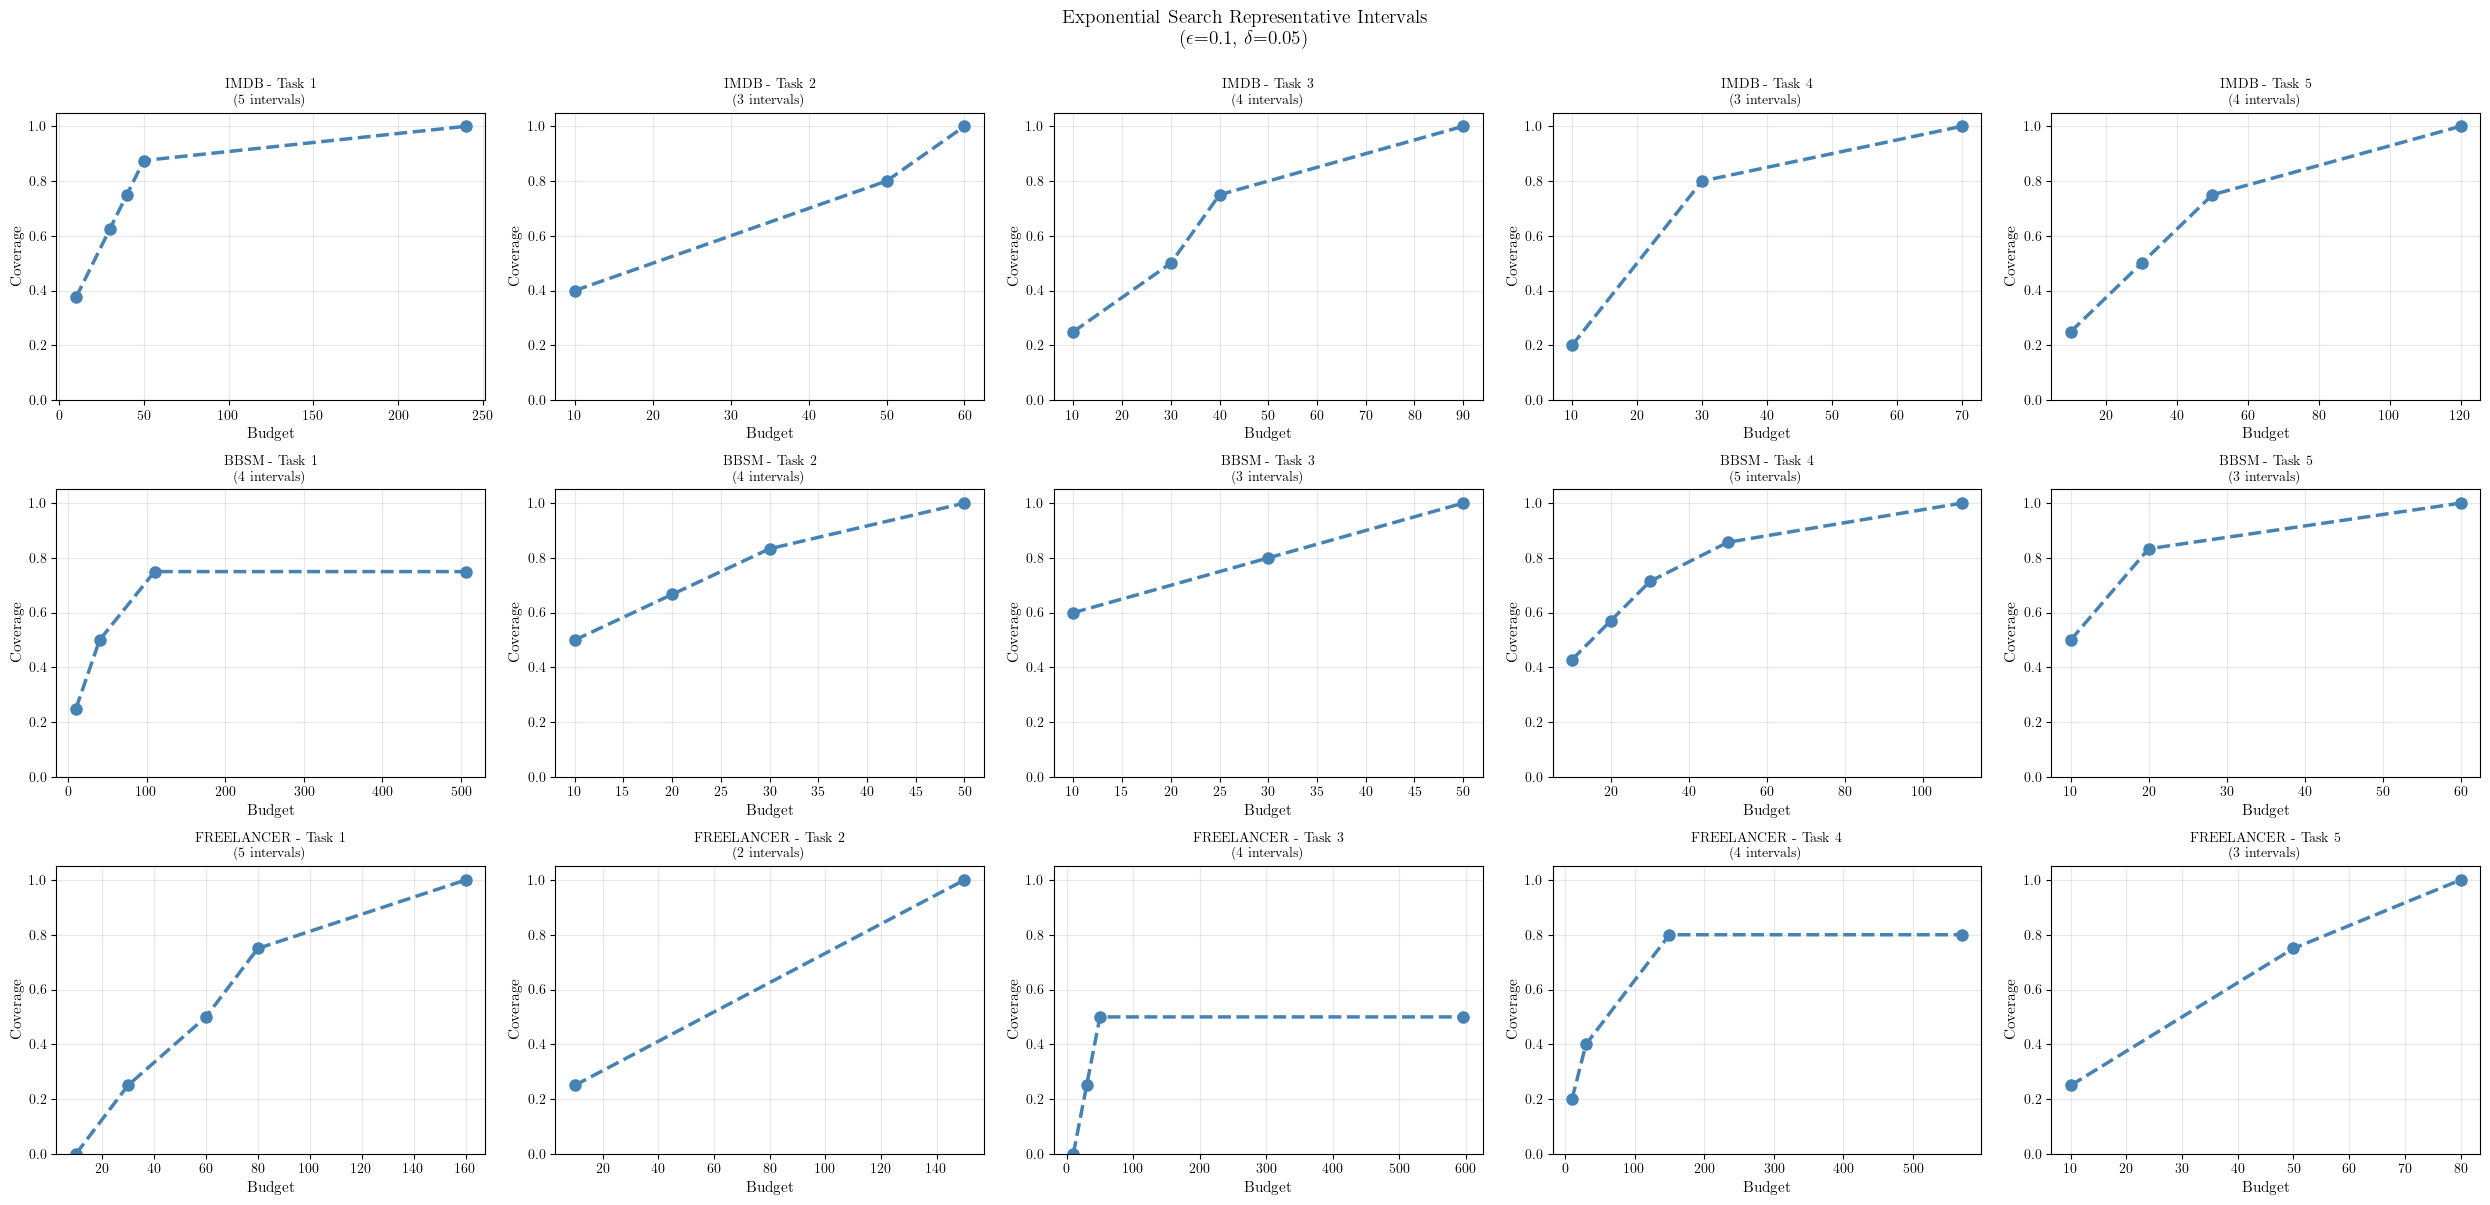

In [19]:
# Create grid of plots for all datasets and tasks
num_datasets = len(datasets)
num_tasks_displayed = max(len(results[d]) for d in results.keys())

fig, axes = plt.subplots(num_datasets, num_tasks_displayed, figsize=(5*num_tasks_displayed, 4*num_datasets))

# Ensure axes is 2D
if num_datasets == 1:
    axes = axes.reshape(1, -1)
if num_tasks_displayed == 1:
    axes = axes.reshape(-1, 1)

# Plot each result
for row, (dataset_name, dataset_results) in enumerate(results.items()):
    for col in range(num_tasks_displayed):
        ax = axes[row, col]
        
        if col in dataset_results:
            result = dataset_results[col]
            coverages = result['coverages']
            budgets = result['budgets']
            
            ax.plot(budgets, coverages, 
                   color='steelblue', linestyle='--', linewidth=2.5, 
                   marker='o', markersize=8, label='Rep. Intervals')
            
            ax.set_xlabel('Budget', fontsize=11, fontweight='bold')
            ax.set_ylabel('Coverage', fontsize=11, fontweight='bold')
            ax.set_title(f'{dataset_name.upper()} - Task {col+1}\n({result["num_intervals"]} intervals)',
                        fontsize=10, fontweight='bold')
            ax.grid(True, alpha=0.3)
            ax.set_ylim([0, 1.05])
        else:
            ax.text(0.5, 0.5, 'No Data', ha='center', va='center', transform=ax.transAxes, fontsize=12)
            ax.set_xticks([])
            ax.set_yticks([])

plt.suptitle(f'Exponential Search Representative Intervals\n($\\epsilon$={epsilon}, $\\delta$={delta})', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()
